# Business Scenario
You have been hired as a Junior Data Analyst for a retail company. Using the provided sales mini-project dataset (customers, products and sales tables), analyze the data and present insights to management.
### Part 1: Data Analysis
- Calculate total revenue.
- Find the average order value.
- Identify the top 10 products by revenue.
- Identify the highest revenue category.
- Find the best-performing region.
- Find the most used payment method.
- Identify the month with the highest sales.
- Find the customer with the most orders.
- Identify the top 5 customers by revenue.

### Part 2:  Data Visualization
 Show
- the top 10 products by revenue
- the monthly sales trend
- the distribution of the payment methods.
- the distribution of order amounts.
- the relationship between quantity vs total revenue.
### Part 3: Business Report
- Write five key findings.
- Provide three recommendations.
- Write a one-page executive summary for the CEO.


### Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


In [2]:
customers = pd.read_csv(r"C:\Users\USER\Downloads\project_customers.csv")
orders = pd.read_csv(r"C:\Users\USER\Downloads\project_orders.csv")
products = pd.read_csv(r"C:\Users\USER\Downloads\project_products.csv")

In [3]:
print(customers.head())
print(orders.head())
print(products.head())

   customer_id   customer_name           city customer_segment signup_date  \
0            1    Cathy Barker          Enugu           Retail  2024-09-22   
1            2  Nicholas Scott          Abuja           Retail  2023-11-22   
2            3    Karen Glover          Lagos           Retail  2026-01-16   
3            4     Erin Palmer         Ibadan              SME  2023-11-02   
4            5  Debra Thompson  Port Harcourt           Retail  2024-05-03   

                      email  
0    mwilkerson@example.com  
1  andrewbenson@example.com  
2        ohenry@example.com  
3    deniselang@example.org  
4                       NaN  
   order_id  customer_id  product_id  order_date  quantity  discount_pct  \
0         1          454          65  2025-11-15         3             0   
1         2          112          26  2026-02-17        10             0   
2         3          288          88  2026-02-02        10             0   
3         4          269          95  2025-08-1

In [4]:
customers.info()
orders.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       500 non-null    int64 
 1   customer_name     500 non-null    object
 2   city              500 non-null    object
 3   customer_segment  500 non-null    object
 4   signup_date       500 non-null    object
 5   email             471 non-null    object
dtypes: int64(1), object(5)
memory usage: 23.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        2000 non-null   int64  
 1   customer_id     2000 non-null   int64  
 2   product_id      2000 non-null   int64  
 3   order_date      2000 non-null   object 
 4   quantity        2000 non-null   int64  
 5   discount_pct    2000 non-null   int64  
 6   sales_

In [5]:
print(customers.describe())
print(orders.describe())
print(products.describe())

       customer_id
count   500.000000
mean    250.500000
std     144.481833
min       1.000000
25%     125.750000
50%     250.500000
75%     375.250000
max     500.000000
          order_id  customer_id   product_id     quantity  discount_pct  \
count  2000.000000  2000.000000  2000.000000  2000.000000    2000.00000   
mean   1000.500000   261.214000    50.363500     5.487500       5.13250   
std     577.494589   150.645382    29.207446     2.897938       5.80834   
min       1.000000     1.000000     1.000000     1.000000       0.00000   
25%     500.750000   129.000000    26.000000     3.000000       0.00000   
50%    1000.500000   261.000000    51.000000     5.000000       5.00000   
75%    1500.250000   397.000000    76.000000     8.000000      10.00000   
max    2000.000000   520.000000   100.000000    10.000000      15.00000   

        total_amount  
count    2000.000000  
mean    75104.812500  
std     86293.126676  
min      2250.000000  
25%     20000.000000  
50%     45000.0

In [6]:
# Checking for missing values
print(customers.isna().sum())
print(orders.isna().sum())
print(products.isna().sum())

customer_id          0
customer_name        0
city                 0
customer_segment     0
signup_date          0
email               29
dtype: int64
order_id          0
customer_id       0
product_id        0
order_date        0
quantity          0
discount_pct      0
sales_channel     0
payment_method    0
total_amount      0
dtype: int64
product_id      0
product_name    0
category        0
unit_price      0
dtype: int64


In [7]:
# Total revenue
total_revenue = orders["total_amount"].sum()
print(total_revenue)

150209625.0


In [8]:
total_revenue = orders["total_amount"].sum()
print(total_revenue)

150209625.0


In [9]:
# Find the average order value
average_order = orders["total_amount"].mean()
print(average_order)

75104.8125


In [10]:
# Identify the top 10 products by revenue.
top_10_products = orders.groupby("product_id")["total_amount"].sum().sort_values(ascending=False).head(10)
print(top_10_products)

product_id
36    6347500.0
85    6200000.0
55    5990000.0
14    5502500.0
81    5182500.0
31    5112500.0
89    4855000.0
75    4177500.0
33    3850000.0
92    3675000.0
Name: total_amount, dtype: float64


In [11]:
# Identify the highest revenue category
# merging the tables
sales = orders.merge(products, on ="product_id", how ="left").merge(customers,on ="customer_id", how ="left")
sales.head()
high_category = sales.groupby("category")["total_amount"].sum().sort_values(ascending =False)
print(high_category)

category
Groceries          38685000.0
Beauty             35581375.0
Electronics        26518750.0
Home Appliances    26314375.0
Fashion            23110125.0
Name: total_amount, dtype: float64


In [12]:
# Find the best-performing region.
regions = sales.groupby("city")["total_amount"].sum().sort_values(ascending = False)
best_region = regions.head(1)

print(regions)
print(best_region)

city
Kano             24377625.0
Port Harcourt    22200125.0
Abuja            21923000.0
Ibadan           21669125.0
Lagos            18495250.0
Benin            17759250.0
Enugu            16590500.0
Name: total_amount, dtype: float64
city
Kano    24377625.0
Name: total_amount, dtype: float64


In [13]:
# Most used payment method
payment_count = sales["payment_method"].value_counts()
most_payment_count= payment_count.idxmax()
print(most_payment_count)

Transfer


In [14]:
sales["order_date"] = pd.to_datetime(sales["order_date"])
sales["month"] =sales['order_date'].dt.month_name()

In [15]:
# Month with highest sales

monthly_revenue = sales.groupby("month")["total_amount"].sum().sort_index().sort_values(ascending = False)
print(monthly_revenue)
top_month = monthly_revenue.idxmax()
print(top_month)

month
July         14516000.0
September    14149250.0
August       13921750.0
May          13553000.0
January      13508750.0
April        13456750.0
November     12994000.0
February     11734250.0
March        11335000.0
October      11031750.0
June         10059250.0
December      9949875.0
Name: total_amount, dtype: float64
July


In [16]:
# Customer with most orders
cust_order_count = sales.groupby("customer_name")["order_id"].count().sort_values(ascending = False)
top_customer = cust_order_count.idxmax()
print(cust_order_count)
print(top_customer)

customer_name
Glenn Bolton       11
Kenneth Olson      10
Stacie Roman       10
Brittany Hall       8
Andre Meadows       8
                   ..
Gregory Willis      1
Jonathan Brewer     1
Theresa Moore       1
Jose Miller         1
Ryan Rocha          1
Name: order_id, Length: 489, dtype: int64
Glenn Bolton


In [17]:
# Top 5 customers by revenue
top_cust_revenue = sales.groupby("customer_name")["total_amount"].sum().sort_values(ascending = False).head(5)
print(top_cust_revenue)

customer_name
Kenneth Olson        1631750.0
Catherine Navarro    1254750.0
Glenn Bolton         1044500.0
Margaret Brown       1008750.0
Leslie Shea           995000.0
Name: total_amount, dtype: float64


In [18]:
top_10_products = (
    sales.groupby("product_name")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

### Data Visualization

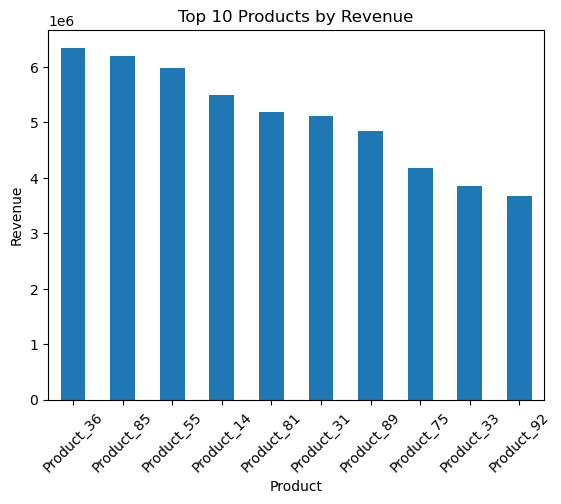

In [19]:
# Data visualization
# Top 10 products
top_10_products.plot(kind ="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

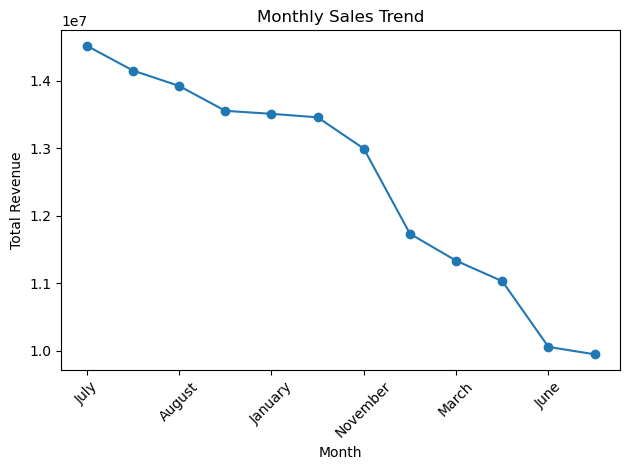

In [20]:
# Monthly sales
monthly_revenue.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

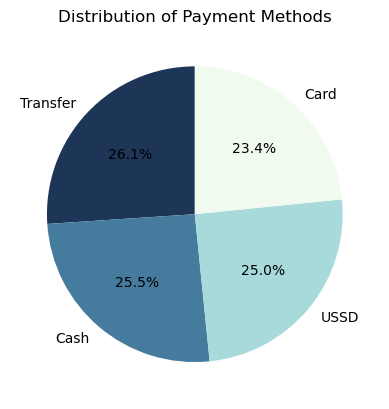

In [27]:
# Payment method
payment_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=['#1D3557', '#457B9D', '#A8DADC', '#F1FAEE']
)

plt.ylabel("")
plt.title("Distribution of Payment Methods")

plt.show()

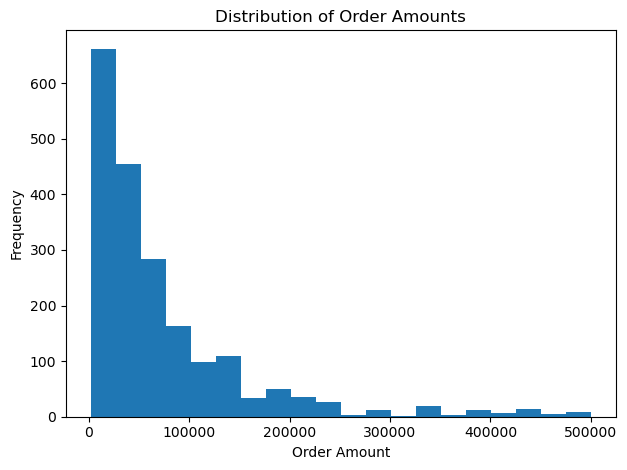

In [22]:
# Distribution of order amounts
plt.hist(
    sales["total_amount"],
    bins=20
)

plt.title("Distribution of Order Amounts")
plt.xlabel("Order Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

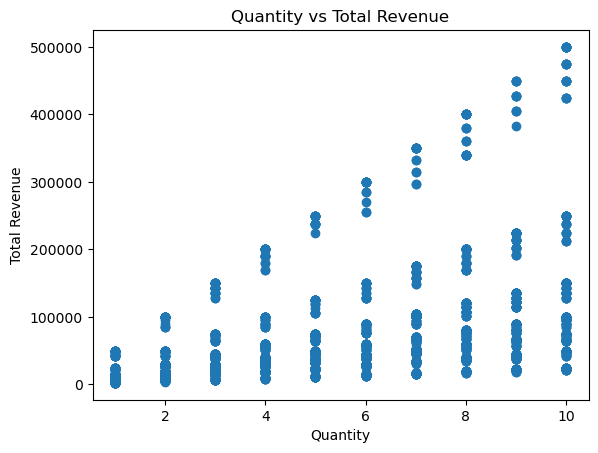

In [23]:
plt.scatter(
    sales["quantity"],
    sales["total_amount"]
)

plt.title("Quantity vs Total Revenue")
plt.xlabel("Quantity")
plt.ylabel("Total Revenue")

plt.tight_layout
plt.show()

#### Create a reusable function that returns the Top N products by revenue

In [24]:
# Python function
def top_n_products(df, n=10):

    top_products = (
        df.groupby("product_name", as_index=False)["total_amount"]
          .sum()
          .rename(columns={"total_amount": "Total Revenue"})
          .sort_values(by="Total Revenue", ascending=False)
          .head(n)
    )

    return top_products

In [25]:
top_n_products(sales, 5)

,product_name,Total Revenue
30,Product_36,6347500.0
84,Product_85,6200000.0
51,Product_55,5990000.0
6,Product_14,5502500.0
80,Product_81,5182500.0


### Business report

#### 1. Revenue is concentrated among a small number of products.
The Top 10 products generated a significant share of total revenue, indicating that a relatively small portion of the product catalogue contributes disproportionately to overall sales. This suggests that customer demand is concentrated around specific high-performing products.
#### 2. Sales showed noticeable monthly fluctuations.
Monthly sales were not consistent throughout the analysis period. Some months recorded significantly higher revenue than others, suggesting the presence of seasonal demand, promotional effects, or changes in customer purchasing behaviour.
#### 3. Customers showed clear preferences for certain payment methods.
The payment method analysis revealed that one or two payment options accounted for the majority of transactions, while other methods were used less frequently. This indicates that customers have preferred payment channels that should remain reliable and readily available.
#### 4. Most orders fall within a similar spending range.
The distribution of order amounts showed that the majority of transactions were concentrated within a moderate value range, while relatively few high-value purchases created a right-skewed distribution. This indicates that large purchases are less common but contribute meaningfully to overall revenue.
#### 5. Quantity purchased has a positive relationship with revenue.
The scatter plot demonstrated a positive relationship between quantity ordered and total revenue. As customers purchased larger quantities, revenue generally increased, although discounts and differences in product pricing introduced some variation across transactions.

### Provide Three Recommendations.
#### 1. Increase investment in top-performing products.
The company should prioritize inventory availability, marketing campaigns, and promotional activities for the highest-revenue products. Ensuring these products remain in stock can maximize sales opportunities and improve customer satisfaction.
#### 2. Develop targeted campaigns during low-sales months.
Since monthly revenue varies over time, management should investigate the causes of lower-performing months and introduce seasonal promotions, discounts, or customer engagement campaigns to stabilize revenue throughout the year.
#### 3. Optimize payment channels and encourage higher-value purchases.
The business should continue supporting customers' preferred payment methods while simplifying less frequently used options. Additionally, bundle offers, quantity discounts, or loyalty incentives can encourage customers to place larger orders, increasing average order value and overall revenue.
